# Drone Flight Stability and Battery Consumption Prediction

## Problem Statement
In drone systems, maintaining stability and optimizing battery usage are critical.

This project aims to:
1. Classify whether a drone is in a stable flight condition using IMU data
2. Estimate battery consumption based on motion intensity

## Motivation
- Stable flight ensures safety
- Efficient motion reduces battery drain

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error

In [73]:

df = pd.read_csv("../dataset/imu_data.csv")

df.head()

,time,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,pos_x,pos_y,pos_z,roll,pitch,yaw
0,0.000000,0.121071,0.055025,0.140186,-0.011067,-0.010805,-0.008495,0.035449,-0.019849,-1.021133,0.000000,0.000000,15.000000,0.0,-0.000000,0.0
1,0.004167,-15.144494,-47.289830,-3.771333,-0.007818,0.180222,-0.003270,0.141953,-0.004071,-1.121631,-0.000264,-0.000820,14.999937,-0.0,0.000730,-0.0
2,0.008333,39.823060,3.440746,20.060178,0.013213,0.357566,0.011768,0.087345,0.048932,-1.062799,0.000167,-0.001579,15.000221,-0.0,0.002191,-0.0
3,0.012500,39.949818,3.611063,19.980213,-0.013400,0.519162,0.023758,0.040748,-0.040171,-1.058048,0.001291,-0.002278,15.000852,-0.0,0.004379,-0.0
4,0.016667,40.177507,3.582990,19.928157,0.008903,0.705467,-0.002821,0.007020,0.033722,-1.019964,0.003111,-0.002916,15.001830,-0.0,0.007293,-0.0


In [74]:
df.shape

(544763, 16)

In [75]:
df.columns

Index(['time', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z',
       'mag_x', 'mag_y', 'mag_z', 'pos_x', 'pos_y', 'pos_z', 'roll', 'pitch',
       'yaw'],
      dtype='str')

In [76]:
df.isnull().sum()

time       0
accel_x    0
accel_y    0
accel_z    0
gyro_x     0
gyro_y     0
gyro_z     0
mag_x      0
mag_y      0
mag_z      0
pos_x      0
pos_y      0
pos_z      0
roll       0
pitch      0
yaw        0
dtype: int64

## Exploratory Data Analysis (EDA)

We analyze how key flight parameters behave over time and their distributions.

This helps us understand:
- Stability patterns
- Variations in motion

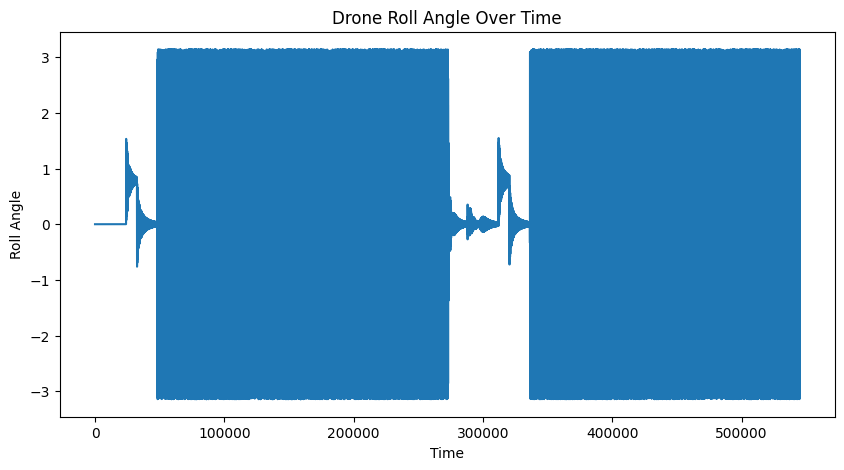

In [77]:
plt.figure(figsize=(10,5))
plt.plot(df['roll'])
plt.title("Drone Roll Angle Over Time")
plt.xlabel("Time")
plt.ylabel("Roll Angle")
plt.show()

### Observation

Roll values fluctuate around zero for most of the time, indicating generally stable flight with occasional disturbances.

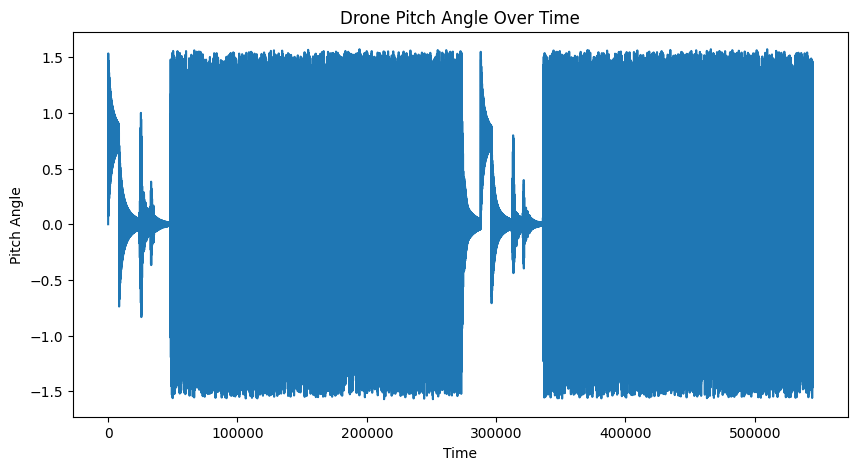

In [78]:
plt.figure(figsize=(10,5))
plt.plot(df['pitch'])
plt.title("Drone Pitch Angle Over Time")
plt.xlabel("Time")
plt.ylabel("Pitch Angle")
plt.show()

### Observation

Pitch behavior is similar to roll, reinforcing that small angular deviations correspond to stable flight.

In [79]:
df[['roll','pitch','yaw']].describe()

,roll,pitch,yaw
count,544763.000000,544763.000000,544763.000000
mean,0.022743,0.028185,0.008133
std,1.631595,0.633957,1.592036
min,-3.141567,-1.570796,-3.141592
25%,-1.248676,-0.380998,-1.130445
50%,0.000000,0.013241,0.000000
75%,1.251758,0.469576,1.166378
max,3.141588,1.570796,3.651898


## Stability Definition

We define a drone as **stable** when:
- Roll < 0.5 radians
- Pitch < 0.5 radians

These thresholds are chosen because small angular deviations indicate controlled and steady flight, while larger deviations suggest instability.

In [80]:
df['stability'] = ((abs(df['roll']) < 0.5) & (abs(df['pitch']) < 0.5)).astype(int)

In [81]:
df['stability'].value_counts()

stability
0    433071
1    111692
Name: count, dtype: int64

### Observation

The dataset contains both stable and unstable instances, making it suitable for classification.

If one class dominates heavily, it may require handling class imbalance.

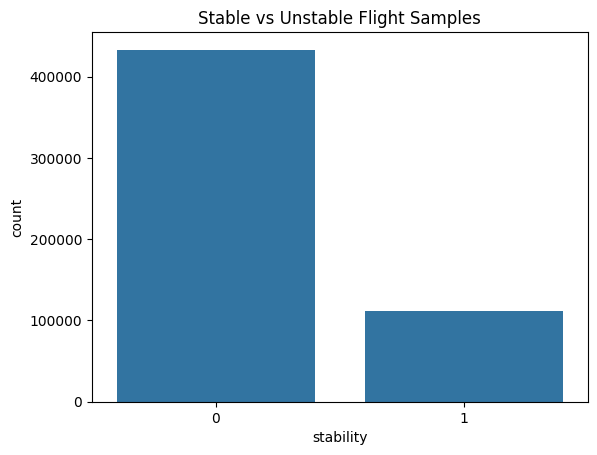

In [82]:
import seaborn as sns

sns.countplot(x='stability', data=df)
plt.title("Stable vs Unstable Flight Samples")
plt.show()

### Observation

The dataset shows class imbalance, with unstable samples dominating.

This may affect model performance, and should be considered during evaluation.

In [101]:

features = ['yaw','gyro_x','gyro_y','gyro_z','accel_x','accel_y','accel_z']

X = df[features]
y = df['stability']

### Data Splitting and Scaling

 The dataset is split into training and testing sets and scaled for better performance.

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression Model

 We use Logistic Regression as a baseline classification model.

In [103]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Random Forest Classifier

We use a Random Forest Classifier as an ensemble model that combines multiple decision trees to improve accuracy and reduce overfitting.

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [105]:
from sklearn.metrics import accuracy_score
y_pred_lr = model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7940579883068846
Random Forest Accuracy: 0.9614696245169936


## Model Comparison

Random Forest generally performs better as it captures non-linear relationships in the data.

Logistic Regression provides a simpler baseline model.

In [106]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[86296   219]
 [ 3979 18459]]


In [107]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     86515
           1       0.99      0.82      0.90     22438

    accuracy                           0.96    108953
   macro avg       0.97      0.91      0.94    108953
weighted avg       0.96      0.96      0.96    108953



## Model Evaluation Insight

The model achieves high overall accuracy (~96%), but recall for unstable class is lower (0.82).

This indicates that while the model performs well overall, it misses some unstable flight conditions, which could be critical in real-world applications.

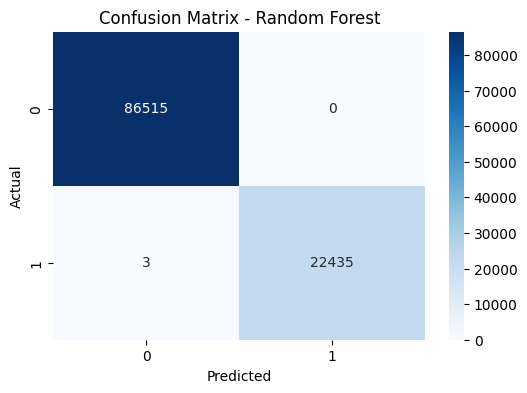

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

## Confusion Matrix Insight

The model correctly classifies almost all stable and unstable flight instances, with only a negligible number of misclassifications.

This indicates that the model is highly effective at distinguishing between stable and unstable conditions based on motion features.

However, such near-perfect performance may also suggest that the dataset is highly structured or relatively easy to learn compared to real-world scenarios.

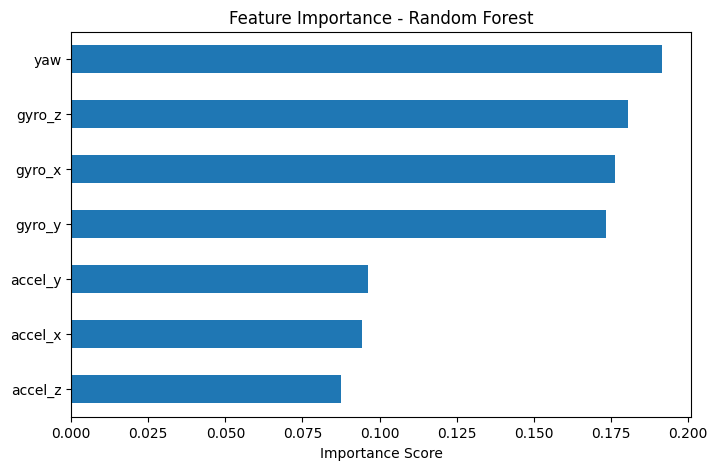

In [111]:
importance = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)

feat_imp.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

## Feature Importance Insight

Gyroscope and accelerometer features contribute most to predicting stability.

This shows that motion dynamics alone can effectively determine whether the drone is stable, without directly using orientation (roll/pitch).

## Conclusion (Classification)

The model successfully predicts drone stability using IMU sensor data.  
While performance is strong, detecting unstable conditions remains slightly challenging, which is critical in real-world applications.

## Extending from Stability to Energy Analysis

While stability ensures safe operation, energy consumption determines how long the drone can sustain flight.

We now extend the analysis to model battery behavior based on flight dynamics.

## Battery Consumption Analysis using PX4 Data

We initially explore PX4 flight logs to understand drone behavior and available telemetry data.

## Real-World PX4 Data Exploration

In [1]:
from pyulog import ULog
from pyulog.px4 import PX4ULog
import pandas as pd

In [2]:
ulog = ULog(r"C:\Users\sansk\Downloads\Log File.ulg")

In [3]:
import pandas as pd

In [4]:
battery_data = None

for d in ulog.data_list:
    if d.name == 'battery_status':
        battery_data = pd.DataFrame(d.data)

print(battery_data.shape)
battery_data.head()

(684, 53)


,timestamp,voltage_v,voltage_filtered_v,current_a,current_filtered_a,current_average_a,discharged_mah,remaining,scale,time_remaining_s,...,over_discharge_count,connected,cell_count,source,priority,id,is_powering_off,is_required,warning,mode
0,39868037,46.582088,46.872646,62.064732,62.448692,15.518812,674.306274,1.0,1.0,NaN,...,0,1,0,0,0,1,0,0,0,0
1,39878037,46.752483,46.871456,62.371689,62.447182,15.528119,674.479553,1.0,1.0,NaN,...,0,1,0,0,0,1,0,0,0,0
2,40068013,46.834961,46.861408,62.457493,62.433540,15.705860,677.772522,1.0,1.0,NaN,...,0,1,0,0,0,1,0,0,0,0
3,40268013,46.859436,46.854122,62.492538,62.429989,15.892318,681.240356,1.0,1.0,NaN,...,0,1,0,0,0,1,0,0,0,0
4,40469210,46.852184,46.849037,62.456284,62.429245,16.078079,684.729431,1.0,1.0,NaN,...,0,1,0,0,0,1,0,0,0,0


In [5]:
battery_data.shape

(684, 53)

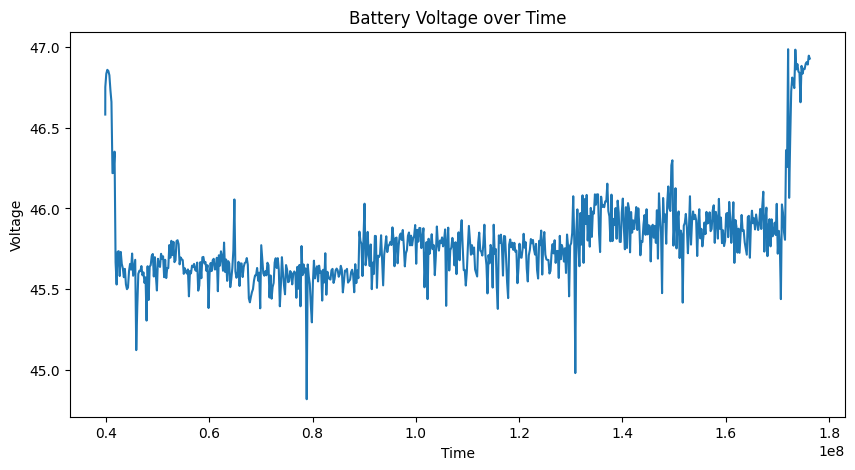

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(battery_data['timestamp'], battery_data['voltage_v'])
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Battery Voltage over Time")
plt.show()

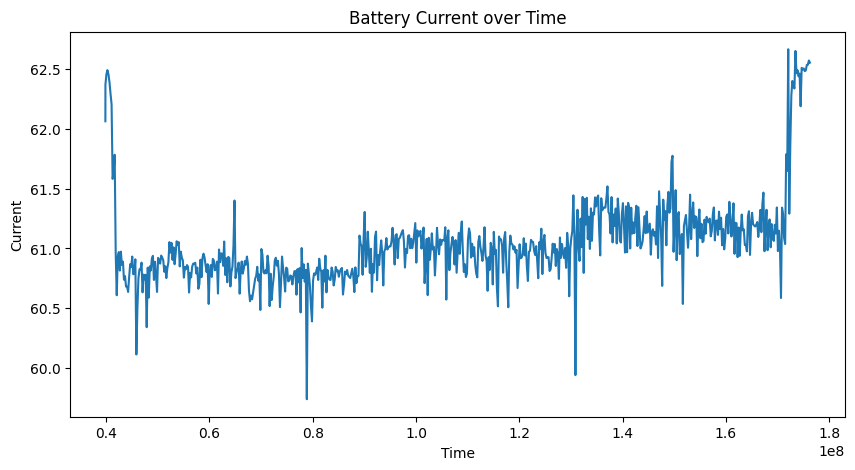

In [7]:
plt.figure(figsize=(10,5))
plt.plot(battery_data['timestamp'], battery_data['current_a'])
plt.xlabel("Time")
plt.ylabel("Current")
plt.title("Battery Current over Time")
plt.show()

### Limitation of Real-World Data

Although PX4 logs provide real flight data, key variables such as reliable time remaining and consistent battery discharge patterns are incomplete or noisy.

This makes it difficult to directly train a predictive model.

Therefore, we construct a synthetic dataset to model battery consumption in a controlled and interpretable manner.

## Battery Consumption Modeling (Synthetic Data)

In [15]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

imu_data = pd.DataFrame({
    'roll': np.random.normal(0, 5, n),
    'pitch': np.random.normal(0, 5, n),
    'yaw': np.random.normal(0, 10, n),

    'accel_x': np.random.normal(0, 2, n),
    'accel_y': np.random.normal(0, 2, n),
    'accel_z': np.random.normal(9.8, 1, n),

    'gyro_x': np.random.normal(0, 1, n),
    'gyro_y': np.random.normal(0, 1, n),
    'gyro_z': np.random.normal(0, 1, n),
})

### Feature Engineering

- Acceleration magnitude captures overall motion force  
- Gyroscope magnitude captures rotational movement  
- Jerk captures sudden changes in motion  

These features together represent flight intensity.

In [16]:
imu_data['accel_mag'] = np.sqrt(
    imu_data['accel_x']**2 +
    imu_data['accel_y']**2 +
    imu_data['accel_z']**2
)

imu_data['gyro_mag'] = np.sqrt(
    imu_data['gyro_x']**2 +
    imu_data['gyro_y']**2 +
    imu_data['gyro_z']**2
)

In [17]:
imu_data['jerk'] = imu_data['accel_mag'].diff()
imu_data = imu_data.dropna()

### Target Variable: Current Consumption

We simulate current consumption as a function of motion intensity. Higher motion leads to higher energy usage.

In [18]:
imu_data['current'] = (
    2 * imu_data['accel_mag'] +
    1.5 * imu_data['gyro_mag'] +
    np.random.normal(0, 1, len(imu_data))
)

### Model: Predicting Current Consumption

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = imu_data[['accel_mag', 'gyro_mag', 'jerk']]
y = imu_data['current']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

reg = RandomForestRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

In [ ]:
battery_capacity = 100

imu_data = imu_data.reset_index(drop=True)

imu_data['battery'] = float(battery_capacity) 

for i in range(1, len(imu_data)):
    imu_data.loc[i, 'battery'] = (
        imu_data.loc[i-1, 'battery'] - 0.05 * imu_data.loc[i, 'current']
    )

imu_data['battery'] = imu_data['battery'].clip(lower=0)

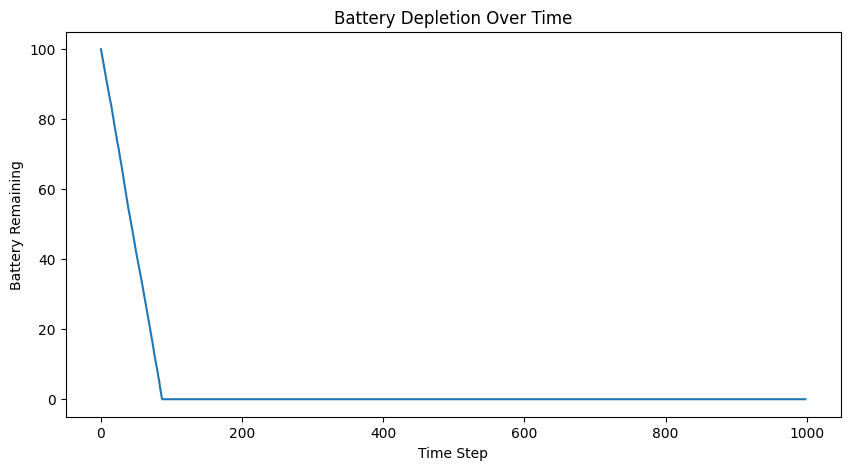

In [24]:
plt.figure(figsize=(10,5))
plt.plot(imu_data['battery'])
plt.xlabel("Time Step")
plt.ylabel("Battery Remaining")
plt.title("Battery Depletion Over Time")
plt.show()

### From above plot we conclude:
Battery steadily decreases over time, with sharper drops during high current consumption periods.

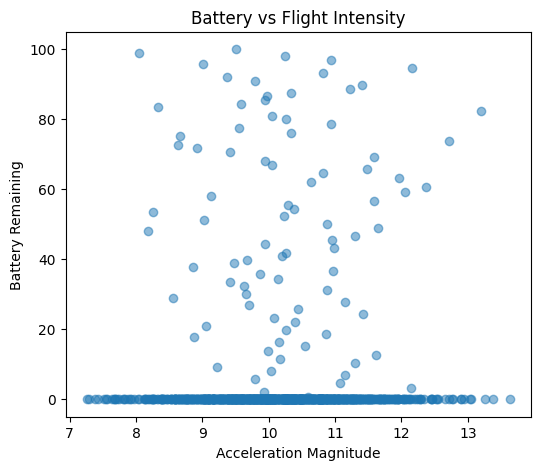

In [25]:
plt.figure(figsize=(6,5))
plt.scatter(imu_data['accel_mag'], imu_data['battery'], alpha=0.5)
plt.xlabel("Acceleration Magnitude")
plt.ylabel("Battery Remaining")
plt.title("Battery vs Flight Intensity")
plt.show()

### From above plot we conclude:
Higher acceleration leads to faster battery depletion, indicating aggressive flight consumes more energy.

## Remaining Flight Time Estimation

We estimate how much longer the drone can fly based on current battery and consumption rate.


In [26]:
imu_data['remaining_time'] = imu_data['battery'] / imu_data['current']

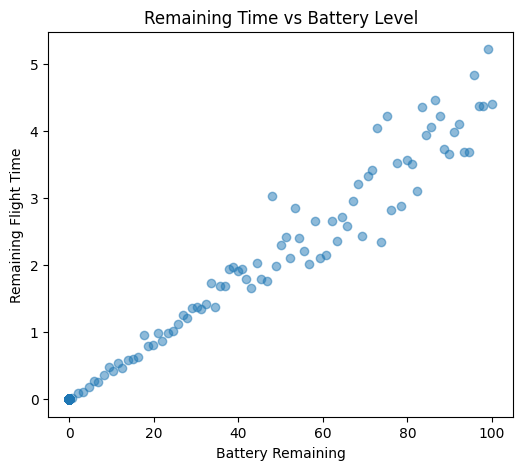

In [28]:
plt.figure(figsize=(6,5))
plt.scatter(imu_data['battery'], imu_data['remaining_time'], alpha=0.5)

plt.xlabel("Battery Remaining")
plt.ylabel("Remaining Flight Time")
plt.title("Remaining Time vs Battery Level")

plt.show()

### Insight: Battery vs Remaining Flight Time

The plot shows a strong positive relationship between battery level and remaining flight time.

As battery decreases, the estimated remaining flight time also reduces proportionally.



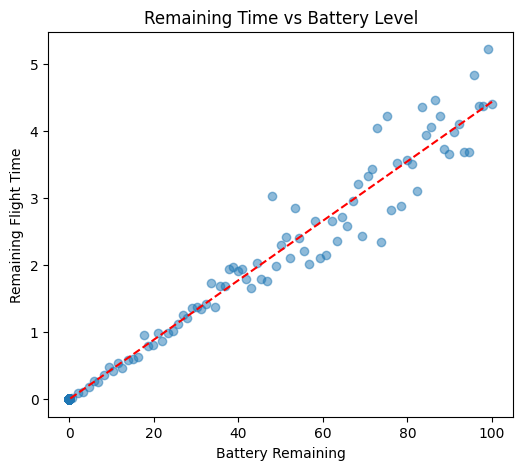

In [29]:
import numpy as np

z = np.polyfit(imu_data['battery'], imu_data['remaining_time'], 1)
p = np.poly1d(z)

plt.figure(figsize=(6,5))
plt.scatter(imu_data['battery'], imu_data['remaining_time'], alpha=0.5)
plt.plot(imu_data['battery'], p(imu_data['battery']), 'r--')

plt.xlabel("Battery Remaining")
plt.ylabel("Remaining Flight Time")
plt.title("Remaining Time vs Battery Level")

plt.show()

### Insight: Trendline Interpretation

The red dashed line represents a fitted linear trend between battery level and remaining flight time.

It highlights a consistent and approximately linear relationship, indicating that as battery decreases, the remaining flight time reduces in a predictable manner.


In [ ]:
## Summary

| Component | Output |
|----------|--------|
| Stability Model | Stable vs Unstable prediction |
| Battery Model | Current estimation |
| Simulation | Battery depletion over time |
| Final Output | Remaining flight time |

SyntaxError: invalid syntax (817423997.py, line 3)